# Estimate parameters (via Optax)

We create some data,
compute the marginal likelihood of this data _under the ODE posterior_
(which is something you cannot do with non-probabilistic solvers!),
and optimize the parameters with `optax`.

Link to paper: https://arxiv.org/abs/2202.01287


In [1]:
"""Estimate ODE parameters with ProbDiffEq and Optax."""

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import optax
from diffeqzoo import backend, ivps

from probdiffeq import ivpsolve, probdiffeq

if not backend.has_been_selected:
    backend.select("jax")  # ivp examples in jax

# Fail this notebook on NaN detection (to catch those in the CI)
jax.config.update("jax_debug_nans", True)

Create a problem and some fake-data:

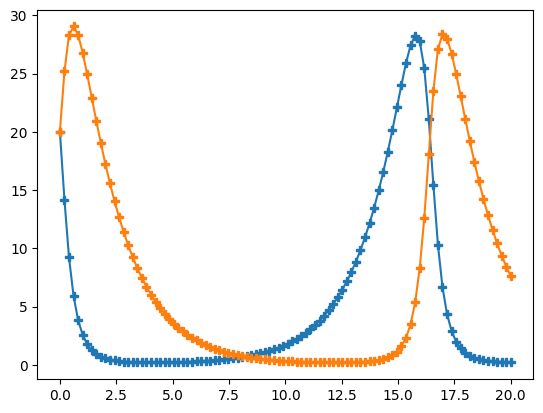

In [2]:
f, u0, (t0, t1), f_args = ivps.lotka_volterra()
f_args = jnp.asarray(f_args)


@jax.jit
def vf(y, t, *, p):  # noqa: ARG001
    """Evaluate the Lotka-Volterra vector field."""
    return f(y, *p)


tcoeffs = (u0, vf(u0, t0, p=f_args))
init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="isotropic")
iwp = probdiffeq.prior_wiener_integrated(ssm=ssm, output_scale=10.0)


def solve(p):
    """Evaluate the parameter-to-solution map."""
    tcoeffs = (u0, vf(u0, t0, p=p))
    init, ssm = probdiffeq.ssm_taylor(tcoeffs, ssm_fact="isotropic")

    def vf_p(y, /, *, t):
        return vf(y, t=t, p=p)

    ts0 = probdiffeq.constraint_ode_ts0(vf_p, ssm=ssm)
    strategy = probdiffeq.strategy_smoother_fixedinterval(ssm=ssm)
    solver = probdiffeq.solver(strategy=strategy, prior=iwp, constraint=ts0, ssm=ssm)
    solve = ivpsolve.solve_fixed_grid(solver=solver)
    return solve(init, grid=ts)


parameter_true = f_args + 0.05
parameter_guess = f_args


ts = jnp.linspace(t0, t1, endpoint=True, num=100)
solution_true = solve(parameter_true)
data = solution_true.u.mean[0]
plt.plot(ts, data, "P-")
plt.show()

We make an initial guess, but it does not lead to a good data fit:

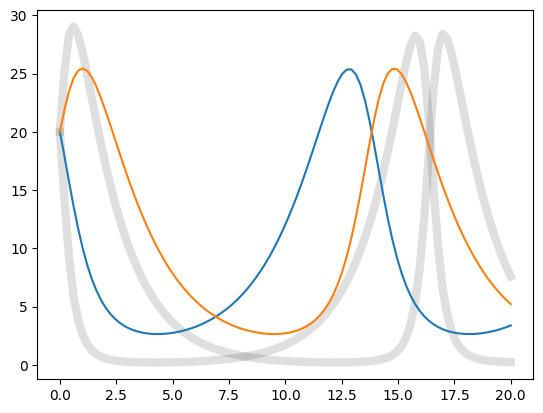

In [3]:
solution_guess = solve(parameter_guess)
plt.plot(ts, data, color="k", linestyle="solid", linewidth=6, alpha=0.125)
plt.plot(ts, solution_guess.u.mean[0])
plt.show()

Use the probdiffeq functionality to compute a parameter-to-data fit function.

This incorporates the likelihood of the data under the distribution induced
by the probabilistic ODE solution
(which was generated with the current parameter guess).

In [4]:
@jax.jit
def parameter_to_data_fit(parameters_, /, std=1e-1):
    """Evaluate the data fit as a function of the parameters."""
    sol_ = solve(parameters_)
    loss_lml = probdiffeq.loss_lml_timeseries(ssm=ssm)
    std = jnp.ones_like(sol_.t) * std
    lml = loss_lml(data, std=std, posterior=sol_.solution_full)
    return -lml


sensitivities = jax.jit(jax.grad(parameter_to_data_fit))

We can differentiate the function forward- and reverse-mode
(the latter is possible because we use fixed steps)

In [5]:
parameter_to_data_fit(parameter_guess)
sensitivities(parameter_guess)

Array([44.611904, 67.776794, 51.73796 , 23.040503], dtype=float32)

Now, enter optax: build an optimizer,
and optimise the parameter-to-model-fit function.
The following is more or less taken from the
[optax-documentation](https://optax.readthedocs.io/en/latest/optax-101.html).

In [6]:
def build_update_fn(*, optimizer, loss_fn):
    """Build a function for executing a single step in the optimization."""

    @jax.jit
    def update(params, opt_state):
        """Update the optimiser state."""
        _loss, grads = jax.value_and_grad(loss_fn)(params)
        updates, opt_state = optimizer.update(grads, opt_state)
        params = optax.apply_updates(params, updates)
        return params, opt_state

    return update


optim = optax.adam(learning_rate=1e-2)
update_fn = build_update_fn(optimizer=optim, loss_fn=parameter_to_data_fit)

In [7]:
p = parameter_guess
state = optim.init(p)

chunk_size = 10
for i in range(chunk_size):
    for _ in range(chunk_size):
        p, state = update_fn(p, state)

    print(f"After {(i + 1) * chunk_size} iterations:", p)

After 10 iterations: [0.42794472 0.04311046 0.42448467 0.05164654]
After 20 iterations: [0.45761883 0.07930805 0.45718187 0.04100043]
After 30 iterations: [0.47889164 0.07980104 0.47683412 0.05482221]
After 40 iterations: [0.49760023 0.07805346 0.4936925  0.0695449 ]
After 50 iterations: [0.51322895 0.08077753 0.50876045 0.07999358]
After 60 iterations: [0.52519584 0.08671875 0.5211439  0.08657544]
After 70 iterations: [0.534501   0.09200823 0.53107536 0.09048022]
After 80 iterations: [0.54103327 0.09547511 0.53797036 0.09362251]
After 90 iterations: [0.5453654  0.09734144 0.5424143  0.09625705]
After 100 iterations: [0.54811186 0.09840008 0.54519975 0.09810966]


The solution looks much better:

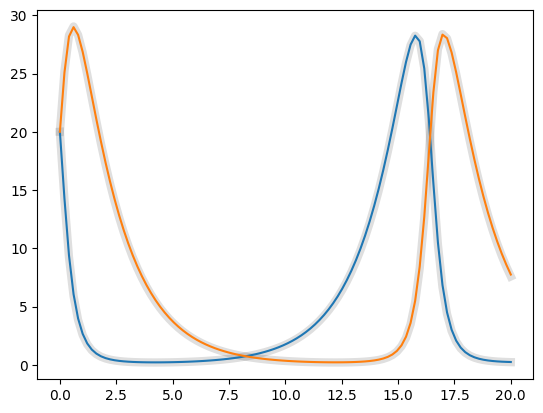

In [8]:
solution_better = solve(p)
plt.plot(ts, data, color="k", linestyle="solid", linewidth=6, alpha=0.125)
plt.plot(ts, solution_better.u.mean[0])
plt.show()